In [1]:
from utils import Exploration, PathFinder

In [2]:
root_path = "./dataset/"

## How to use Exploration

The `Exploration` class leverages the OpenLaneV2 API to analyze and visualize lane sequences within a dataset. By specifying a sequence, you can interactively explore frames, update position and connection maps or visualize the discovered nodes and their relationships. This workflow helps you understand the structure and connectivity of lane segments in your chosen sequence.

In [3]:
exp = Exploration(root_path)

collecting data_dict_sample_ls: 100%|███████████| 96/96 [00:02<00:00, 44.26it/s]


After initializing the `Exploration` class, we begin exploring the selected sequence to analyze lane connectivity and visualize frame data. This step sets the foundation for understanding the dataset structure before moving on to pathfinding and network analysis.

In [4]:
sequence = 1
exp.start_exploration(sequence)

Now let's visualize frames at intervals of 6, which corresponds to approximately every 3 seconds. This approach provides a clearer overview of the sequence progression and lane connectivity throughout the dataset.

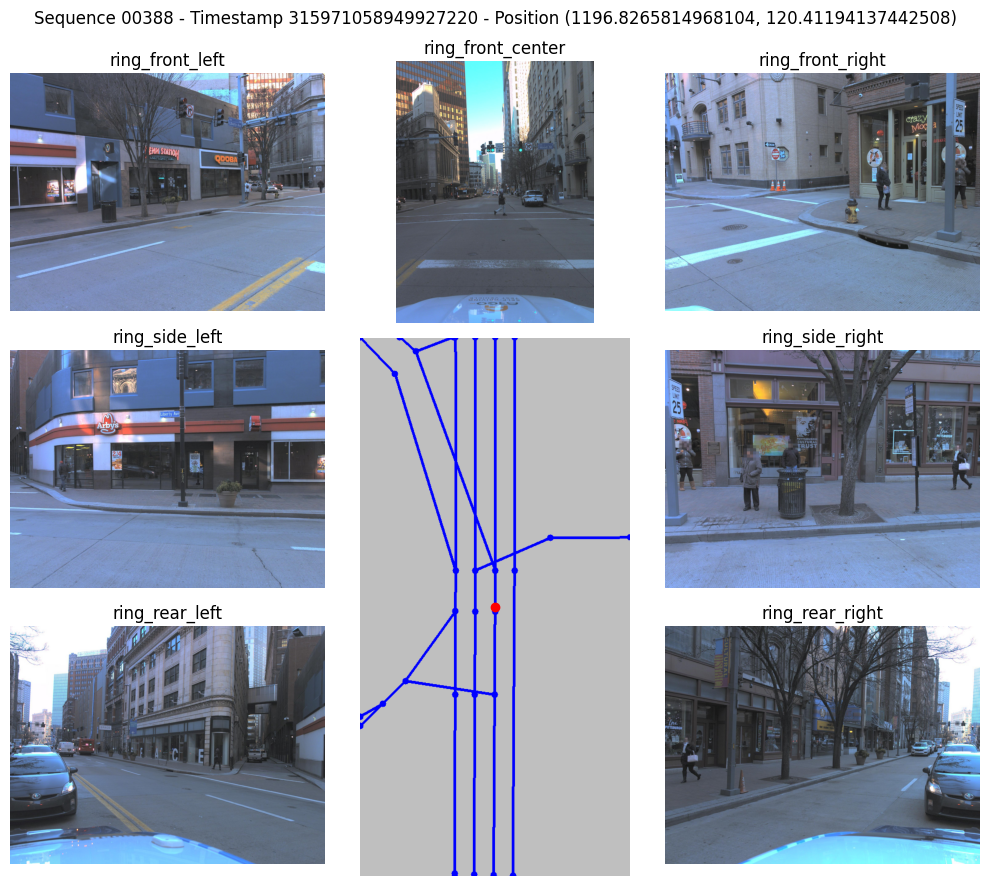

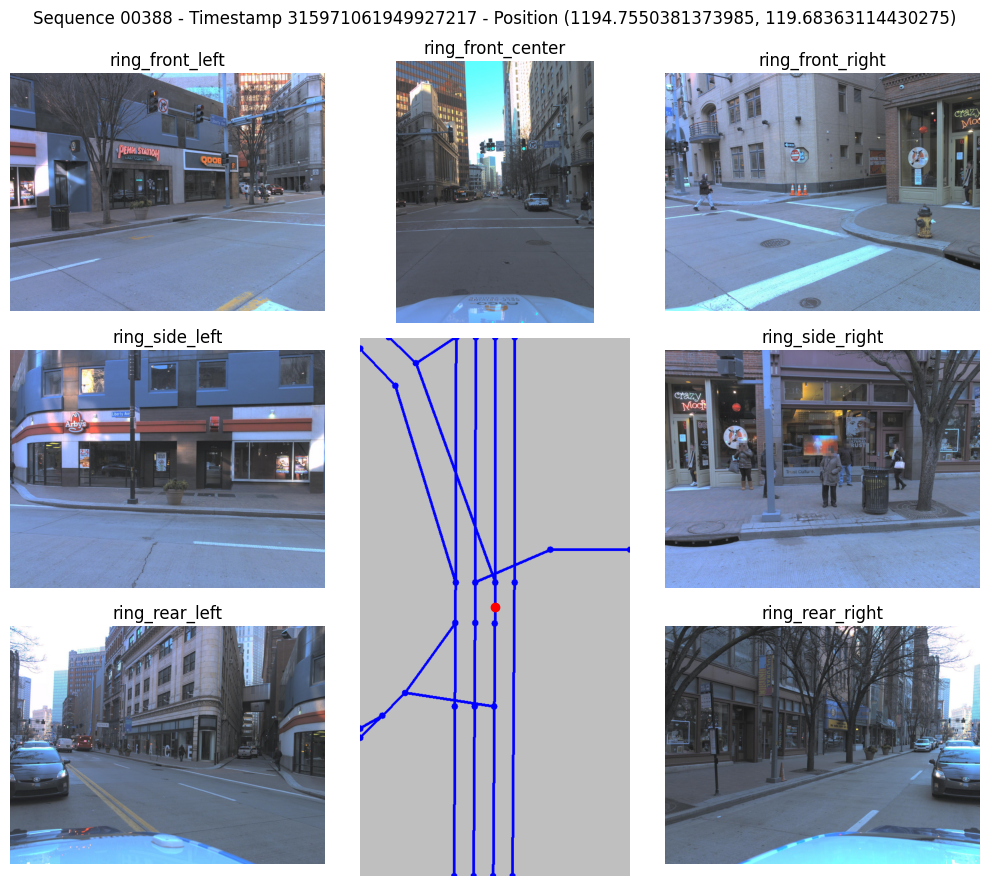

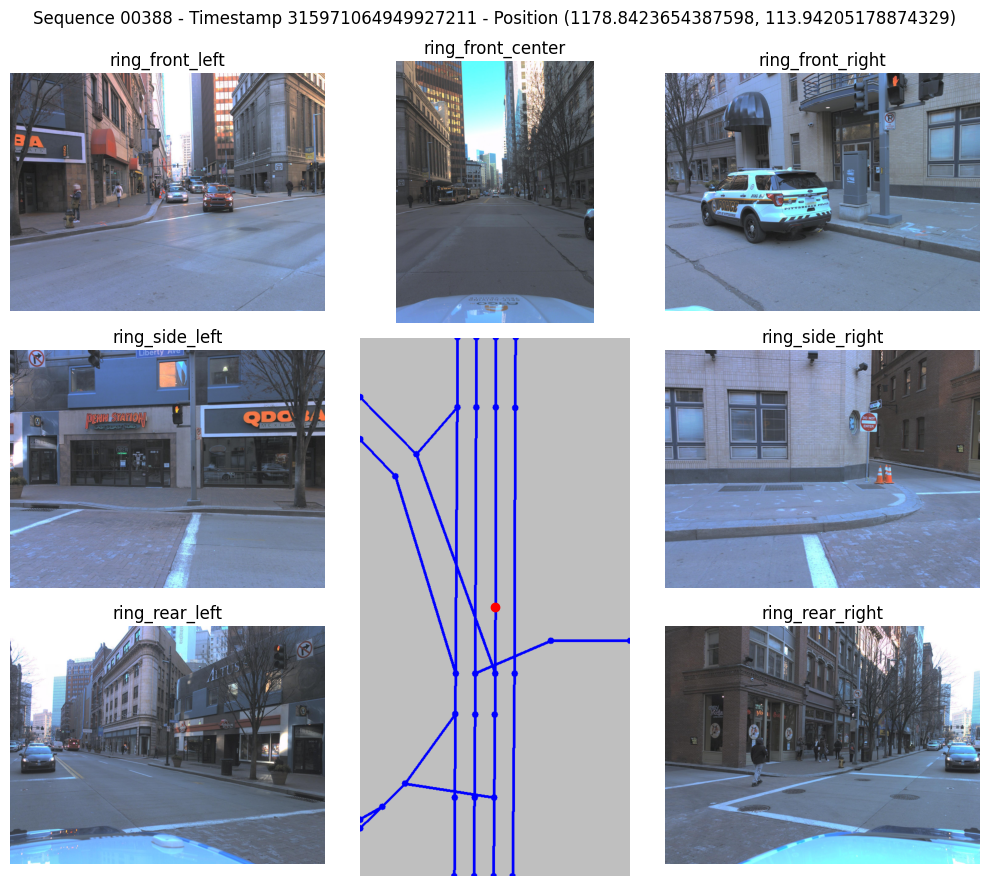

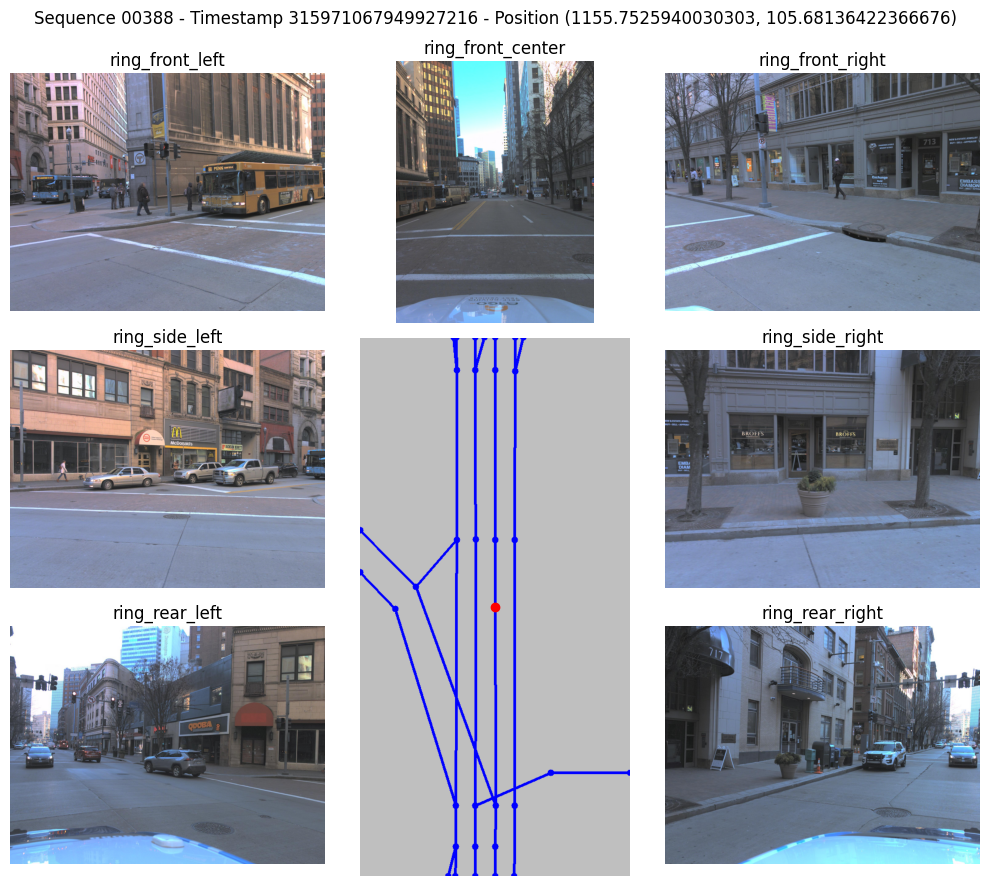

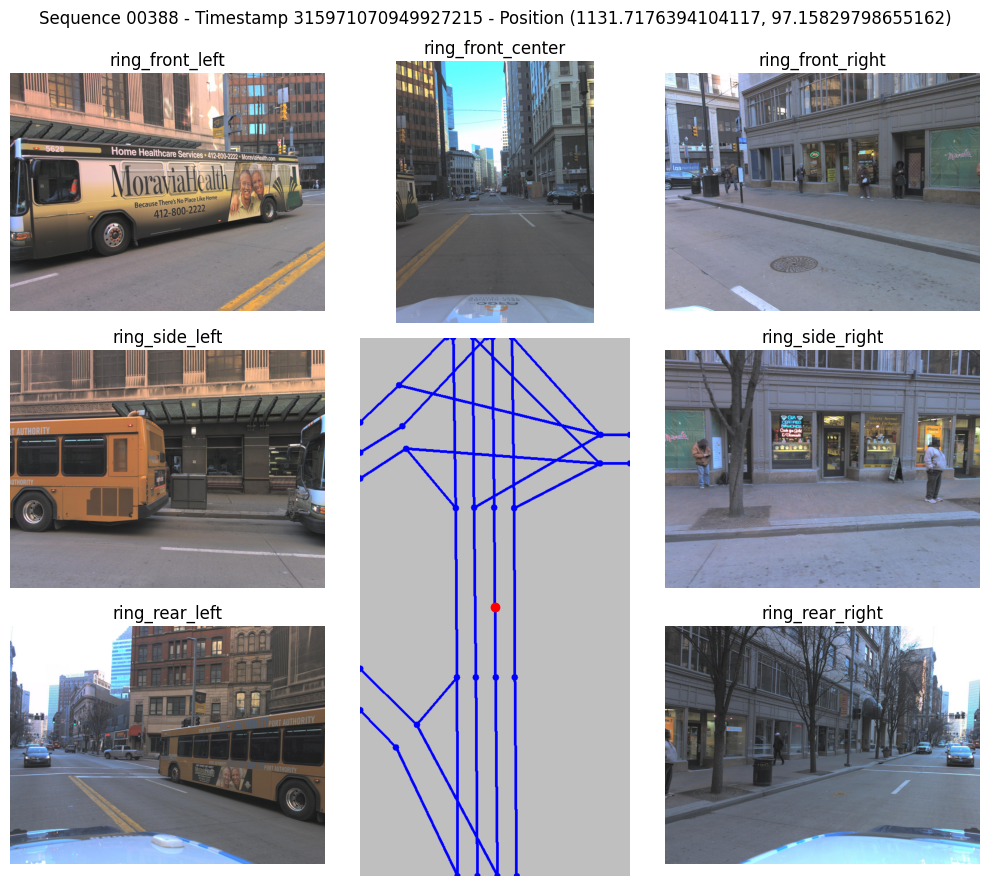

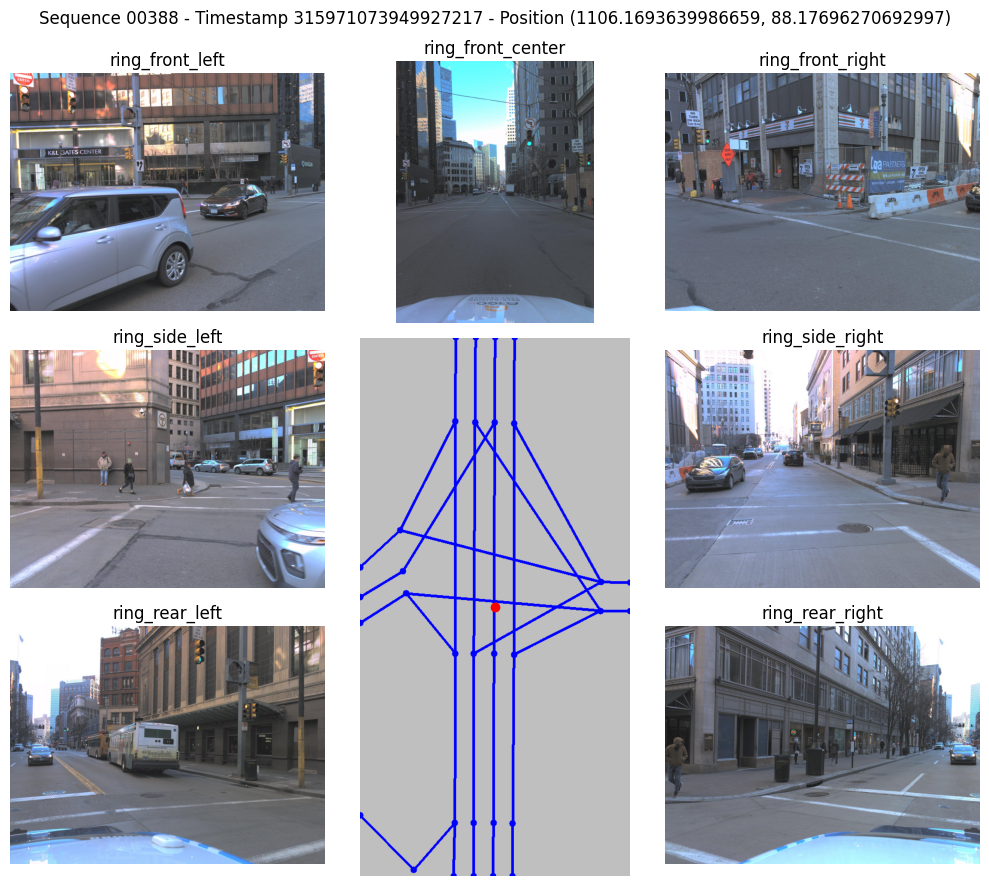

In [ ]:
step = 6
for idx in range(0, 32, step):
    _, frame = exp.collection.get_frame_via_index(idx)
    exp.plot_frame(frame, show_plot=True)

During each step of exploration, the `Exploration` class dynamically updates its position and connection maps. These maps are stored as dictionaries, allowing us to understand the relationships and connectivity between discovered nodes.

To visualize the resulting network of nodes and their connections, we use `networkx`. Below, we display the final constellation plot for the selected sequence, providing a clear overview of the lane connectivity using the nodes IDs.

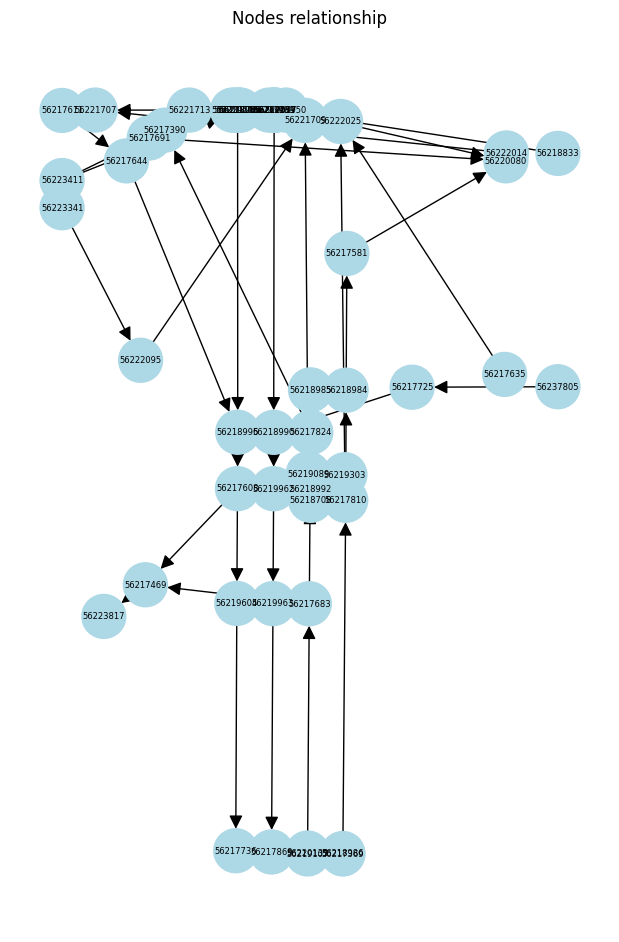

In [6]:
exp.plot_constellation(show_plot=True)

Now we have a fully connected network of nodes that can be leveraged for advanced pathfinding and analysis.

## How to use PathFinder

The `PathFinder` class inherits from `Exploration` and utilizes the constructed connectivity map to compute optimal paths between nodes. To find the shortest path from the start of a sequence to a specified goal, we use the A* algorithm provided by `PathFinder`. Below is an example demonstrating how to initialize the class and retrieve the best path :

In [9]:
sequence  = 2
pf        = PathFinder(root_path, sequence)
best_path = pf.A_star()

collecting data_dict_sample_ls: 100%|███████████| 96/96 [00:02<00:00, 44.45it/s]



Starting at node 59682446 (717, 2615) to node 59683487 (738, 2673)


The `A_star` method returns the optimal path as a list of node IDs, representing the shortest route from the starting point to the goal within the lane network. To visually interpret this path, we use the `plot_constellation` function, which highlights the discovered route on the network graph. This visualization helps us understand how the algorithm navigates through the lane connectivity map from start to goal.

Found path : ['59682446', '59682604', '59682462', '59683487']


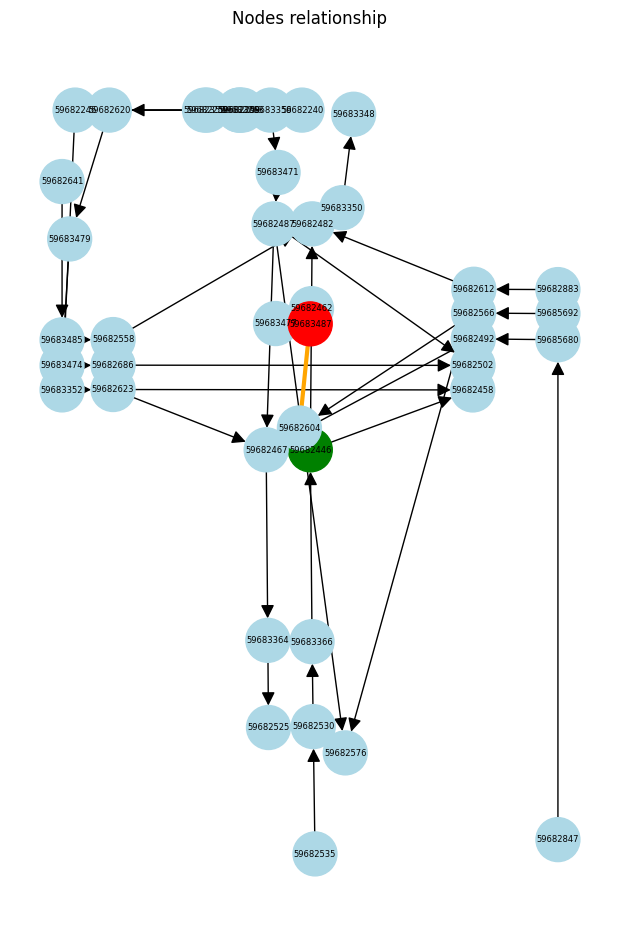

In [10]:
print("Found path :", best_path)
pf.plot_constellation(node_start=pf.start_node, node_goal=pf.goal_node, list_path=best_path, show_plot=True)

## Conclusion

The `utils.py` tool, featuring the `Exploration` and `PathFinder` classes, streamlines the process of analyzing lane connectivity and computing optimal paths within the OpenLaneV2 dataset. By using exploration, dynamic visualization and A star pathfinding algorithms, the agent can interpret lane structures and relationships. This workflow supports both visual inspection and algorithmic analysis.